Actividad individual 2: Análisis de componentes principales (PCA)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

Objetivo: Realizar un análisis de componentes principales dentro de la base de datos "Tarea 2_Base alumnos prepa.csv"

In [2]:
# 2) Cargar y preparar los datos (Load and data preparation)
path = "Tarea 2_Base alumnos prepa.csv"
df = pd.read_csv(path, encoding="latin1")

# Seleccionar solo columnas numéricas
num_df = df.select_dtypes(include=[np.number]).copy()

# Crear reporte de forma
shape_report = pd.DataFrame({
    "metric": ["rows_total", "cols_total", "cols_numeric"],
    "value": [df.shape[0], df.shape[1], num_df.shape[1]]
})

# Imputar valores faltantes con la media de cada columna numérica
num_df_imputed = num_df.fillna(num_df.mean(numeric_only=True))

# Mostrar resultados
print("Dataset (primeras 12 filas):")
print(df.head(12))
print("\nSubset numérico con imputación de media (primeras 12 filas):")
print(num_df_imputed.head(12))
print("\nReporte de forma:")
print(shape_report)

Dataset (primeras 12 filas):
            ID_TEXT        ID_TEXT.1            CIUDAD     REGION  \
0    Entrevistado_1   Entrevistado_1    AGUASCALIENTES      BAJIO   
1    Entrevistado_2   Entrevistado_2           MORELIA      BAJIO   
2    Entrevistado_3   Entrevistado_3         MONTERREY      NORTE   
3    Entrevistado_4   Entrevistado_4       GUADALAJARA      BAJIO   
4    Entrevistado_5   Entrevistado_5            CANCÚN        SUR   
5    Entrevistado_6   Entrevistado_6             TEPIC  OCCIDENTE   
6    Entrevistado_7   Entrevistado_7       GUADALAJARA      BAJIO   
7    Entrevistado_8   Entrevistado_8             TEPIC  OCCIDENTE   
8    Entrevistado_9   Entrevistado_9  TUXTLA GUTIÉRREZ        SUR   
9   Entrevistado_10  Entrevistado_10    AGUASCALIENTES      BAJIO   
10  Entrevistado_11  Entrevistado_11       GUADALAJARA      BAJIO   
11  Entrevistado_12  Entrevistado_12  TUXTLA GUTIÉRREZ        SUR   

               TIPO UNIVERSIDAD_EVALUADA_NACIONAL  \
0   Primera mención 

In [4]:

# 3) Estandarizar las variables
scaler = StandardScaler()
X_scaled = scaler.fit_transform(num_df_imputed.values)

scaled_df = pd.DataFrame(
    X_scaled,
    columns=num_df_imputed.columns,
    index=num_df_imputed.index
)

print("Primeras filas estandarizadas:")
print(scaled_df.head(10))

Primeras filas estandarizadas:
   PRESTIGIO DE LA INSTITUCIÓN  NIVEL ACADÉMICO  \
0                     1.091811         0.132824   
1                    -0.781149         0.132824   
2                     1.091811        -1.410648   
3                    -0.156829        -0.896157   
4                     0.467491         0.647315   
5                    -0.156829        -1.410648   
6                     0.092899         0.647315   
7                     0.467491         1.161806   
8                    -0.156829         0.132824   
9                     1.091811        -0.381666   

   OFERTA ACADÉMICA (CARRERAS OFERTADAS)  PROFESORES  
0                              -2.375048   -1.000697  
1                               0.320858    0.123998  
2                              -1.027095    0.123998  
3                              -0.577778    0.686345  
4                               0.230994   -2.125391  
5                               0.320858    0.123998  
6                     

In [5]:
# 4) Construir la matriz de correlación (correlation matrix)

corr_matrix = np.corrcoef(X_scaled, rowvar=False)

corr_df = pd.DataFrame(
    corr_matrix,
    index=num_df_imputed.columns,
    columns=num_df_imputed.columns
)

print("Matriz de correlación (variables numéricas):")
print(corr_df.round(3))

Matriz de correlación (variables numéricas):
                                       PRESTIGIO DE LA INSTITUCIÓN  \
PRESTIGIO DE LA INSTITUCIÓN                                  1.000   
NIVEL ACADÉMICO                                             -0.000   
OFERTA ACADÉMICA (CARRERAS OFERTADAS)                        0.020   
PROFESORES                                                   0.002   

                                       NIVEL ACADÉMICO  \
PRESTIGIO DE LA INSTITUCIÓN                     -0.000   
NIVEL ACADÉMICO                                  1.000   
OFERTA ACADÉMICA (CARRERAS OFERTADAS)            0.017   
PROFESORES                                       0.025   

                                       OFERTA ACADÉMICA (CARRERAS OFERTADAS)  \
PRESTIGIO DE LA INSTITUCIÓN                                            0.020   
NIVEL ACADÉMICO                                                        0.017   
OFERTA ACADÉMICA (CARRERAS OFERTADAS)                                  1.

Conclusión antes de PCA:
El dataset está “bien condicionado”: no hay multicolinealidad fuerte.

In [6]:
# 5) Calcular autovalores y autovectores (eigen decomposition)

eig_vals, eig_vecs = np.linalg.eig(corr_matrix)

# Ordenar de mayor a menor
idx_sorted = np.argsort(eig_vals)[::-1]
eig_vals_sorted = eig_vals[idx_sorted].real
eig_vecs_sorted = eig_vecs[:, idx_sorted].real

# Calcular proporciones de varianza explicada
total_var = eig_vals_sorted.sum().real
explained_ratio_eig = (eig_vals_sorted / total_var).real
cum_explained_eig = np.cumsum(explained_ratio_eig)

# Resumen de resultados
eig_summary = pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(len(eig_vals_sorted))],
    "eigenvalue": eig_vals_sorted,
    "explained_variance_ratio": explained_ratio_eig,
    "cumulative_explained_variance": cum_explained_eig
})

print("Resumen de autovalores y varianza explicada (desde la matriz de correlación):")
print(eig_summary.round(4))


Resumen de autovalores y varianza explicada (desde la matriz de correlación):
    PC  eigenvalue  explained_variance_ratio  cumulative_explained_variance
0  PC1      1.0358                    0.2590                         0.2590
1  PC2      1.0116                    0.2529                         0.5119
2  PC3      0.9833                    0.2458                         0.7577
3  PC4      0.9693                    0.2423                         1.0000


In [7]:
# 6) Seleccionar número de componentes principales (Kaiser and 75% cumulative)
kaiser_mask = eig_vals_sorted > 1.0
n_kaiser = int(kaiser_mask.sum())
n_cum = int(np.argmax(cum_explained_eig >= 0.75) + 1) if len(eig_vals_sorted) > 0 else 0
n_components = max(n_kaiser, n_cum) if n_cum > 0 else n_kaiser if n_kaiser > 0 else min(2, len(eig_vals_sorted))
selection_report = pd.DataFrame({
"criterion": ["Kaiser (>1.0)", "Cumulative >= 0.75", "Final chosen n_components"],
"value": [n_kaiser, n_cum, n_components]
})
print("Component selection report", selection_report)

Component selection report                    criterion  value
0              Kaiser (>1.0)      2
1         Cumulative >= 0.75      3
2  Final chosen n_components      3


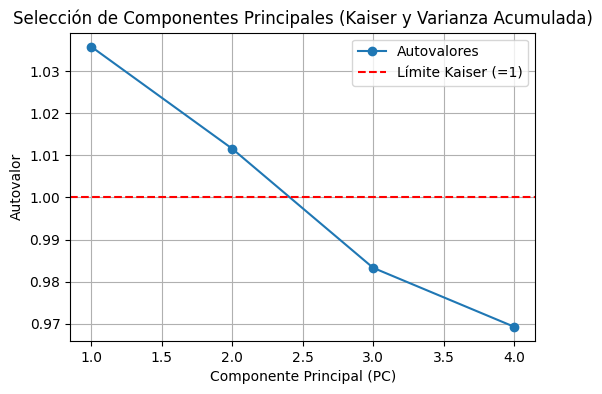

In [9]:
#  6B) Visualización de la selección de componentes 

# Gráfico de autovalores y varianza explicada
plt.figure(figsize=(6,4))
plt.plot(range(1, len(eig_vals_sorted)+1), eig_vals_sorted, 'o-', label='Autovalores')
plt.axhline(1, color='red', linestyle='--', label='Límite Kaiser (=1)')
plt.xlabel("Componente Principal (PC)")
plt.ylabel("Autovalor")
plt.title("Selección de Componentes Principales (Kaiser y Varianza Acumulada)")
plt.legend()
plt.grid(True)
plt.show()


In [10]:
# 7) Calcular los componentes principales (Fit PCA)

# Aplicar PCA con el número de componentes seleccionados
pca = PCA(n_components=n_components, svd_solver="full")
X_pca = pca.fit_transform(X_scaled)

# Varianza explicada
explained_ratio = pca.explained_variance_ratio_
cum_explained = np.cumsum(explained_ratio)

pca_summary = pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(n_components)],
    "explained_variance_ratio": explained_ratio,
    "cumulative_explained_variance": cum_explained
})
print("Resumen PCA (scikit-learn):")
print(pca_summary.round(4))

# Loadings: contribución de cada variable a cada componente
loadings = pd.DataFrame(
    pca.components_.T,
    index=num_df_imputed.columns,
    columns=[f"PC{i+1}" for i in range(n_components)]
)
print("\nContribución de las variables (Loadings):")
print(loadings.round(4))

# Scores: proyección de cada observación en los nuevos componentes
pca_scores_df = pd.DataFrame(
    X_pca,
    columns=[f"PC{i+1}" for i in range(n_components)],
    index=num_df_imputed.index
)

# Guardar los resultados
output_path = "Tarea2_PCA_scores.csv"
pca_scores_df.to_csv(output_path, index=False)
print(f"\nScores del PCA guardados en: {output_path}")


Resumen PCA (scikit-learn):
    PC  explained_variance_ratio  cumulative_explained_variance
0  PC1                    0.2590                         0.2590
1  PC2                    0.2529                         0.5119
2  PC3                    0.2458                         0.7577

Contribución de las variables (Loadings):
                                          PC1     PC2     PC3
PRESTIGIO DE LA INSTITUCIÓN            0.3185  0.6821  0.5529
NIVEL ACADÉMICO                        0.5987 -0.3590 -0.3170
OFERTA ACADÉMICA (CARRERAS OFERTADAS)  0.5336  0.4358 -0.5162
PROFESORES                             0.5053 -0.4648  0.5722

Scores del PCA guardados en: Tarea2_PCA_scores.csv


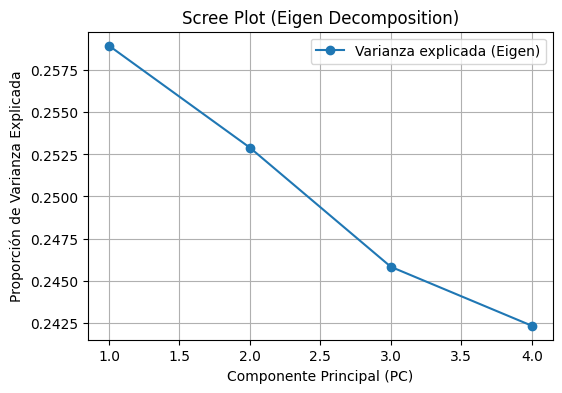

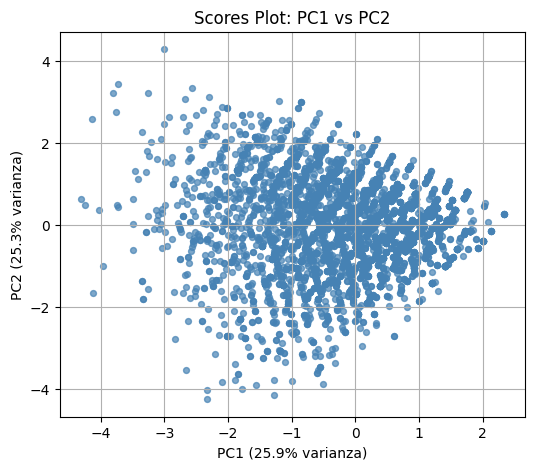

In [11]:
# 8) Visualizar e interpretar los resultados (Visualize and Interpret the Results)

# 1) Scree Plot: autovalores o varianza explicada
plt.figure(figsize=(6,4))
plt.plot(range(1, len(eig_vals_sorted) + 1), explained_ratio_eig, marker="o", label="Varianza explicada (Eigen)")
plt.title("Scree Plot (Eigen Decomposition)")
plt.xlabel("Componente Principal (PC)")
plt.ylabel("Proporción de Varianza Explicada")
plt.grid(True)
plt.legend()
plt.show()

# 2) Scores Plot: proyección de observaciones
if n_components >= 2:
    plt.figure(figsize=(6,5))
    plt.scatter(X_pca[:, 0], X_pca[:, 1], s=18, c='steelblue', alpha=0.7)
    plt.title("Scores Plot: PC1 vs PC2")
    plt.xlabel(f"PC1 ({explained_ratio[0]*100:.1f}% varianza)")
    plt.ylabel(f"PC2 ({explained_ratio[1]*100:.1f}% varianza)")
    plt.grid(True)
    plt.show()


k vs inertia: [(2, np.float64(8193.47)), (3, np.float64(4946.61)), (4, np.float64(4070.05)), (5, np.float64(3393.22)), (6, np.float64(2881.52)), (7, np.float64(2490.17)), (8, np.float64(2175.88)), (9, np.float64(1933.14))]
k vs silhouette: [(2, np.float64(0.363)), (3, np.float64(0.415)), (4, np.float64(0.334)), (5, np.float64(0.327)), (6, np.float64(0.336)), (7, np.float64(0.341)), (8, np.float64(0.343)), (9, np.float64(0.35))]

Clusters asignados con k=3. Silhouette=0.415

Primeras filas con etiqueta de cluster:
          ID_TEXT       ID_TEXT.1          CIUDAD REGION             TIPO  \
0  Entrevistado_1  Entrevistado_1  AGUASCALIENTES  BAJIO  Primera mención   
1  Entrevistado_2  Entrevistado_2         MORELIA  BAJIO  Primera mención   
2  Entrevistado_3  Entrevistado_3       MONTERREY  NORTE  Primera mención   
3  Entrevistado_4  Entrevistado_4     GUADALAJARA  BAJIO  Primera mención   
4  Entrevistado_5  Entrevistado_5          CANCÚN    SUR  Primera mención   

  UNIVERSIDAD_EVAL

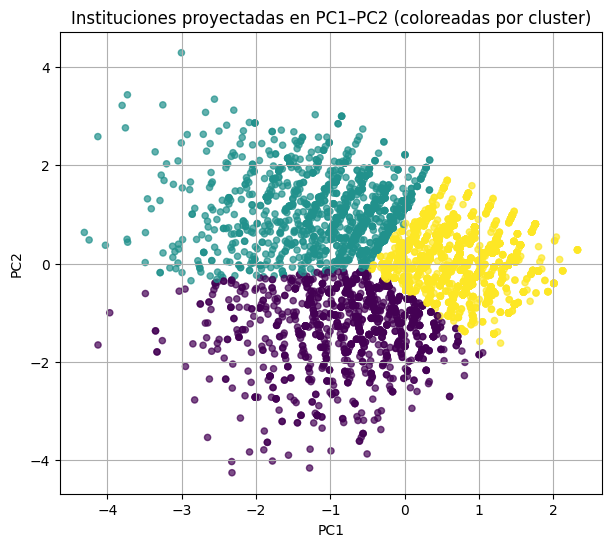

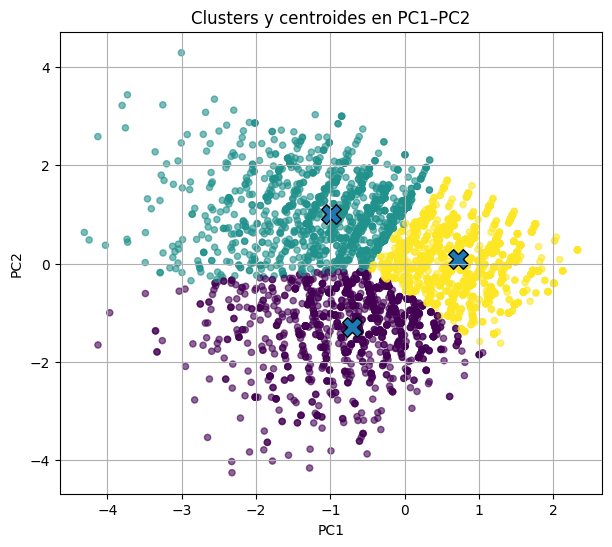

In [16]:
# 9) Aplicar PCA en el contexto del negocio
# PCA + K-Means para segmentar instituciones educativas
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Datos base
# Usaremos las 2 primeras componentes principales (PC1 y PC2)
Z = X_pca[:, :2]

# 1) BÚSQUEDA RÁPIDA DE K
inertias = []
sil_scores = []
K = range(2, 10)

for k in K:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(Z)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(Z, labels))

print("k vs inertia:", list(zip(K, np.round(inertias, 2))))
print("k vs silhouette:", list(zip(K, np.round(sil_scores, 3))))

# 2) SELECCIÓN DEL MEJOR K
k_best = K[int(np.argmax(sil_scores))]
kmeans = KMeans(n_clusters=k_best, n_init=10, random_state=42)
cluster_labels = kmeans.fit_predict(Z)
print(f"\nClusters asignados con k={k_best}. Silhouette={max(sil_scores):.3f}")

# 3) AÑADIR CLUSTERS AL DATAFRAME
df_clusters = df.copy()
df_clusters["Cluster"] = cluster_labels
print("\nPrimeras filas con etiqueta de cluster:")
print(df_clusters.head())

# 4) VISUALIZACIÓN DE CLUSTERS
plt.figure(figsize=(7,6))
scatter = plt.scatter(Z[:,0], Z[:,1], c=cluster_labels, s=20, alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Instituciones proyectadas en PC1–PC2 (coloreadas por cluster)")
plt.grid(True)
plt.show()

# Marcar centroides
centroids = kmeans.cluster_centers_
plt.figure(figsize=(7,6))
plt.scatter(Z[:,0], Z[:,1], c=cluster_labels, s=20, alpha=0.6)
plt.scatter(centroids[:,0], centroids[:,1], s=200, marker='X', edgecolor='black')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Clusters y centroides en PC1–PC2")
plt.grid(True)
plt.show()
